## Задание
Цель:
Вспомнить и применить знания, полученные на протяжении всего курса. Получить полноценную работу, объединяющую в себе основные методики по работе с данными и алгоритмы машинного обучения.

Описание задания:
В лабораторной работе предлагается решить задачу классификации. Данные для выполнения работы можно скачать по ссылке, нажав на Data Folder. В датасете находится информация о флаге и базовых показателях страны. На основе доступной информации решается задача классификации стран по религии. Целевой признак мультиклассовый – religion. Остальные признаки описывают характерные черты флага и самой страны. Подробное описание признаков и их возможные значения можно прочесть на сайте.

Решение работы не высылается и будет разобрано на лекции.


Этапы работы:

1. Получите данные и загрузите их в рабочую среду. (Jupyter Notebook или другую)
2. Проведите первичный разведочный анализ данных.
-  Проверьте данные на пропуски.
- Постройте 1-2 графика на выбор. Визуализация должна быть основана на исследуемых данных и быть полезной (из графика можно сделать вывод об особенностях датасета/класса/признака).
3. Разделите выборку на обучающее и тестовое подмножество. 80% данных оставить на обучающее множество, 20% на тестовое.
4. Обучите любую модель классификации на выбор.
5. Для тестового множества сделайте предсказание целевой переменной. Выведите метрики модели с помощью metrics.classification_report. Можно использовать любой другой альтернативный метод подсчета метрик.
6. Посчитайте и выведите корреляционную матрицу. Убедитесь, что ячейки матрицы поделены на цветные категории, в ячейках указано числовое значение корреляции.
- Сделайте выводы.
7. Обработайте выбросы в данных.
-  Визуализируйте распределение значений для каждой переменной. Можно использовать функции sns.boxplot, sns.distplot.
- Исследуйте признаки на выбросы. Удалите выбросы, если они были найдены/вы считаете это необходимым.
8. Проведите нормализацию признаков.
- Выберите признаки для нормализации, предложите способы для их обработки.
9. Повторите п. 4, п. 5.
10. Сбалансируйте классы путем oversampling/undersampling.
-  Повторите п. 4, п. 5.
11. Уменьшите размерность пространства признаков.
-  Повторите п. 4, п. 5.
12. Примените любой метод на ваше усмотрение для отбора признаков.
-  Повторите п. 4, п. 5. Укажите количество выбранных признаков.
13. Оптимизируйте параметры модели из п. 4.
-  Повторите п. 4, п. 5.
14. Обучите стекинг трех моделей, включая модель с оптимизированными параметрами.
15. Выберите результат с лучшими метриками и постройте для него Confusion Matrix.
16. *Творческий пункт. Предложите что-то интересное для датасета.
17. Сделайте выводы

In [76]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score,precision_score
from sklearn.metrics import classification_report
import seaborn as sns

In [8]:

import warnings
warnings.filterwarnings("ignore")

In [9]:
flag_data = pd.read_csv('/Users/sofagusina/Desktop/программирование/machine_learning/machine_learning/ML/Работа с признаками/Final work/flags/flag.data')
flag_data.columns = [
    "name",
    "landmas",
    "zone",
    "area",
    "population",
    "language",
    "religion",
    "bars",
    "stripes",
    "colours",
    "red",
    "green",
    "blue",
    "gold",
    "white",
    "black",
    "orange",
    "mainhue",
    "circles",
    "crosses",
    "saltires",
    "quarters",
    "sunstars",
    "crescent",
    "triangle",
    "icon",
    "animate",
    "text",
    "topleft",
    "botright"
]
flag_data

,name,landmas,zone,area,population,language,religion,bars,stripes,colours,...,saltires,quarters,sunstars,crescent,triangle,icon,animate,text,topleft,botright
0,Albania,3,1,29,3,6,6,0,0,3,...,0,0,1,0,0,0,1,0,red,red
1,Algeria,4,1,2388,20,8,2,2,0,3,...,0,0,1,1,0,0,0,0,green,white
2,American-Samoa,6,3,0,0,1,1,0,0,5,...,0,0,0,0,1,1,1,0,blue,red
3,Andorra,3,1,0,0,6,0,3,0,3,...,0,0,0,0,0,0,0,0,blue,red
4,Angola,4,2,1247,7,10,5,0,2,3,...,0,0,1,0,0,1,0,0,red,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,Western-Samoa,6,3,3,0,1,1,0,0,3,...,0,1,5,0,0,0,0,0,blue,red
189,Yugoslavia,3,1,256,22,6,6,0,3,4,...,0,0,1,0,0,0,0,0,blue,red
190,Zaire,4,2,905,28,10,5,0,0,4,...,0,0,0,0,0,1,1,0,green,green
191,Zambia,4,2,753,6,10,5,3,0,4,...,0,0,0,0,0,0,1,0,green,brown


Первичный анализ данных

In [10]:
flag_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        193 non-null    object
 1   landmas     193 non-null    int64 
 2   zone        193 non-null    int64 
 3   area        193 non-null    int64 
 4   population  193 non-null    int64 
 5   language    193 non-null    int64 
 6   religion    193 non-null    int64 
 7   bars        193 non-null    int64 
 8   stripes     193 non-null    int64 
 9   colours     193 non-null    int64 
 10  red         193 non-null    int64 
 11  green       193 non-null    int64 
 12  blue        193 non-null    int64 
 13  gold        193 non-null    int64 
 14  white       193 non-null    int64 
 15  black       193 non-null    int64 
 16  orange      193 non-null    int64 
 17  mainhue     193 non-null    object
 18  circles     193 non-null    int64 
 19  crosses     193 non-null    int64 
 20  saltires  

In [11]:
list_unique = {}
for col in flag_data.columns:
   list_unique[col] =  flag_data[col].unique()
list_unique

{'name': array(['Albania', 'Algeria', 'American-Samoa', 'Andorra', 'Angola',
        'Anguilla', 'Antigua-Barbuda', 'Argentina', 'Argentine',
        'Australia', 'Austria', 'Bahamas', 'Bahrain', 'Bangladesh',
        'Barbados', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
        'Bolivia', 'Botswana', 'Brazil', 'British-Virgin-Isles', 'Brunei',
        'Bulgaria', 'Burkina', 'Burma', 'Burundi', 'Cameroon', 'Canada',
        'Cape-Verde-Islands', 'Cayman-Islands', 'Central-African-Republic',
        'Chad', 'Chile', 'China', 'Colombia', 'Comorro-Islands', 'Congo',
        'Cook-Islands', 'Costa-Rica', 'Cuba', 'Cyprus', 'Czechoslovakia',
        'Denmark', 'Djibouti', 'Dominica', 'Dominican-Republic', 'Ecuador',
        'Egypt', 'El-Salvador', 'Equatorial-Guinea', 'Ethiopia', 'Faeroes',
        'Falklands-Malvinas', 'Fiji', 'Finland', 'France', 'French-Guiana',
        'French-Polynesia', 'Gabon', 'Gambia', 'Germany-DDR',
        'Germany-FRG', 'Ghana', 'Gibraltar', 'Greece', 'G

В данных нет каких-то странных значений и пропусков, выраженных знаками вопроса и другими посторонними символами

Обучение модели классификации с помощью деревьев решений, логистической регресиии и алгоритма SVC

In [14]:
X = flag_data[[
    "landmas",
    "zone",
    "area",
    "population",
    "language"]]
Y = flag_data['religion']

In [15]:
X_train,X_test,y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
tree_model = DecisionTreeClassifier(max_depth=8)

In [18]:
tree_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=8)

In [19]:
y_pred = tree_model.predict(X_test)

In [20]:
tree_model.score(X_test,y_test)

0.717948717948718

У алгоритма дерева решений достаточно низкая метрика accuracy, вероятно, это связано с большим количеством выбросов, либо признаки не нормализированы

Обучение модели логистической регрессии

In [21]:
from sklearn.linear_model import LogisticRegression
model_log = LogisticRegression()

In [22]:

model_log.fit(X_train,y_train)

y_pred_log = model_log.predict(X_test)

In [23]:
model_log.score(X_test,y_test)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.67      0.47      0.55        17
           2       0.22      0.80      0.35         5
           3       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.33      0.33      0.33         3
           7       0.00      0.00      0.00         0

    accuracy                           0.33        39
   macro avg       0.17      0.23      0.18        39
weighted avg       0.34      0.33      0.31        39



Модель демонстрирует низкое качество

Обучение модели метода опорных векторов (SVC)

In [24]:
from sklearn.svm import SVC

In [25]:
svc_model = SVC(kernel='rbf')

In [26]:
svc_model.fit(X_train,y_train)

SVC()

In [27]:
y_pred_svc = svc_model.predict(X_test)

In [28]:
print(classification_report(y_test.to_numpy(), y_pred_svc.astype(int)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.42      0.82      0.56        17
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         3

    accuracy                           0.36        39
   macro avg       0.07      0.14      0.09        39
weighted avg       0.18      0.36      0.24        39



Метрики  немного увеличились по сравнению с моделью логистической регресии, но меньше, чем для модели деревьев решений

<Axes: >

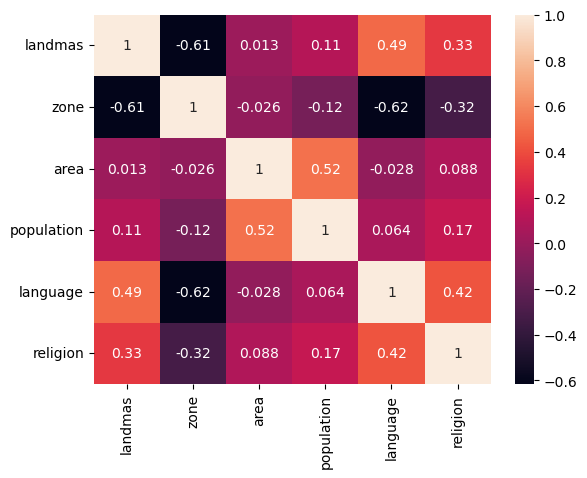

In [29]:
data_flag_reset = flag_data[["landmas",
    "zone",
    "area",
    "population",
    "language",
    "religion"]].corr()
sns.heatmap(data_flag_reset,annot=True)

Высокую корреляцию имеют столбцы - area и population (площадь страны и ее население), zone и language, zone и landmas
Вся корреляция логична

В целевой переменной коррелируют столбцы landmas, language

Промежуточный вывод: все три модели показали очень слабое качество работы, вероятно, это связано с самими данными. Попробуем преобразовать данные и посмотреть новые метрики моделей

Проверка выбросов в данных

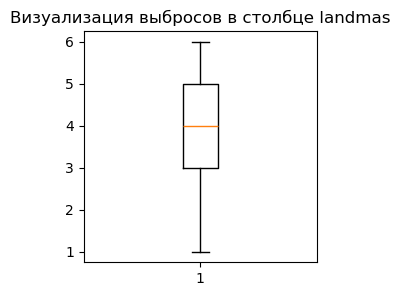

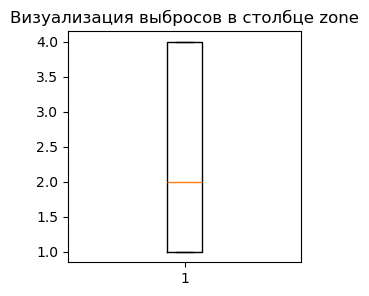

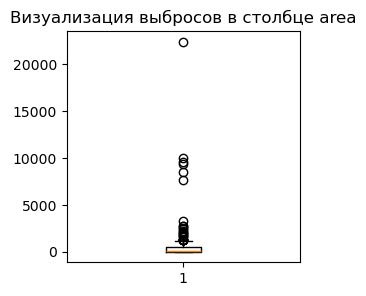

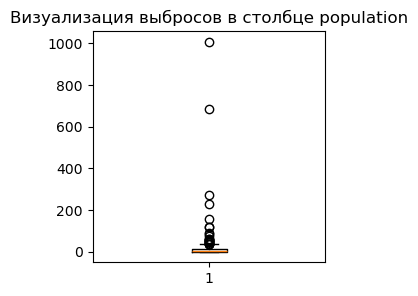

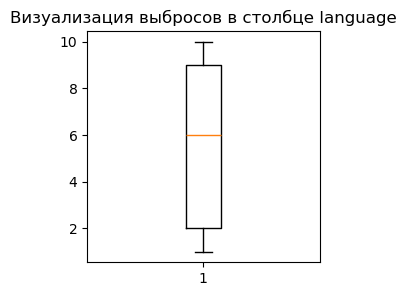

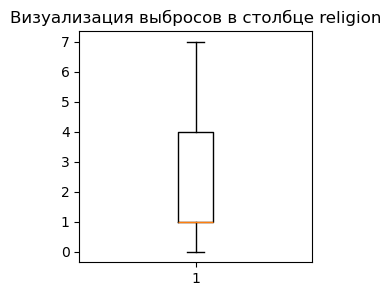

In [30]:
columns = [
    "landmas",
    "zone",
    "area",
    "population",
    "language",
    "religion"]
for column in columns:
    plt.figure(figsize=(3,3))
    plt.boxplot(flag_data[column])
    plt.title(f"Визуализация выбросов в столбце {column}")
    plt.show()


Выбросы наблюдаются в столбцах area и population. В других столбцах нет выбросов, но, вероятно, это связано не с хорошим качеством данных, а с ненормализированными признаками



Проведем работу с выбросами

In [31]:
flag_data.groupby('name')['area'].median()

name
Albania             29.0
Algeria           2388.0
American-Samoa       0.0
Andorra              0.0
Angola            1247.0
                   ...  
Western-Samoa        3.0
Yugoslavia         256.0
Zaire              905.0
Zambia             753.0
Zimbabwe           391.0
Name: area, Length: 193, dtype: float64

In [32]:
for column in ['area','population']:
    iqr= flag_data[column].quantile(0.75) - flag_data[column].quantile(0.25)
    lower_bound = flag_data[column].quantile(0.25) - 1.5 * iqr
    upper_bound = flag_data[column].quantile(0.75) + 1.5 * iqr
    outliers = []
    for el in flag_data[column]:
        if el < lower_bound or el > upper_bound:
            if el not in outliers:
                outliers.append(el)
                el = np.nan
    print(f"Outliers in column {column}: - {len(outliers)}", outliers, )
# flag_data.describe()

Outliers in column area: - 24 [2388, 1247, 2777, 7690, 8512, 9976, 1284, 9561, 1222, 2176, 3268, 1904, 1648, 1760, 1240, 1973, 1566, 1267, 1285, 2150, 1221, 2506, 9363, 22402]
Outliers in column population: - 22 [90, 119, 1008, 47, 54, 61, 684, 157, 39, 57, 118, 77, 56, 84, 48, 36, 38, 49, 45, 231, 274, 60]


Заменим выбросы медианой по группам - сгруппируем данные по стране

In [33]:
flag_data['area'] = flag_data['area'].fillna(flag_data.groupby('name')['area'].median())
flag_data['population'] = flag_data['population'].fillna(flag_data.groupby('name')['population'].median())


Далее проведем нормализацию признаков

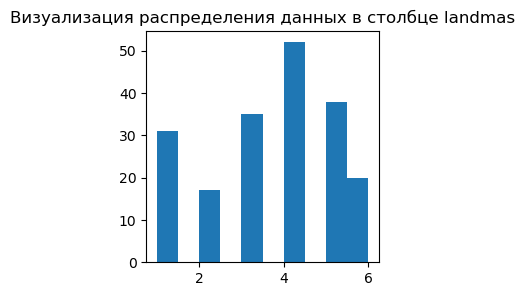

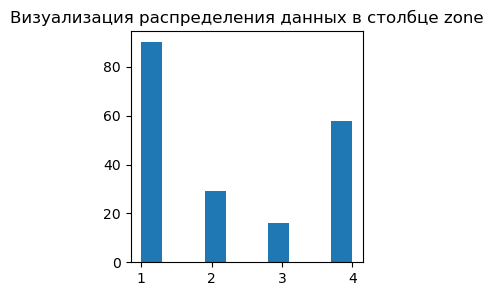

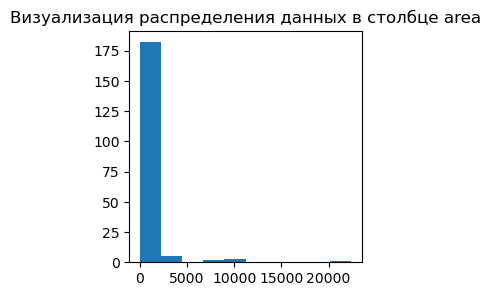

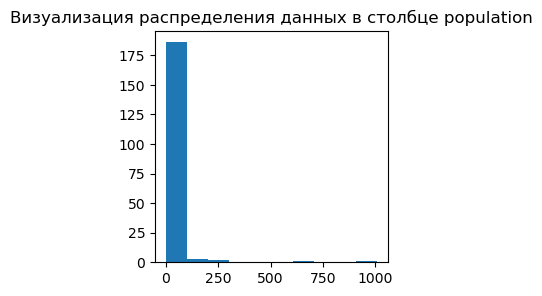

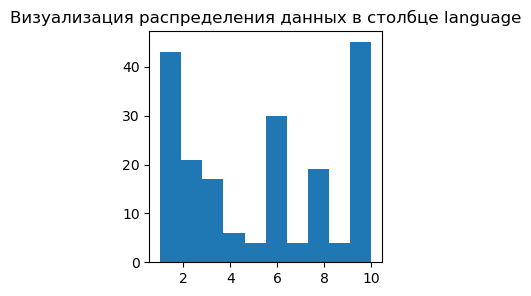

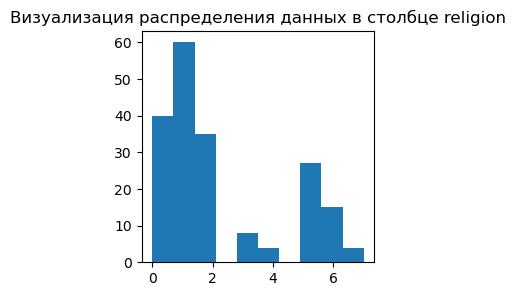

In [34]:
for column in columns:
    plt.figure(figsize=(3,3))
    plt.hist(flag_data[column])
    plt.title(f"Визуализация распределения данных в столбце {column}")
    plt.show()

Также можно привести данные в столбцах area и population к нормальному распределению


In [35]:
flag_data.describe()

,landmas,zone,area,population,language,religion,bars,stripes,colours,red,...,circles,crosses,saltires,quarters,sunstars,crescent,triangle,icon,animate,text
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,...,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,3.564767,2.217617,700.316062,23.305699,5.316062,2.191710,0.455959,1.544041,3.455959,0.787565,...,0.170984,0.150259,0.093264,0.150259,1.388601,0.056995,0.139896,0.248705,0.202073,0.082902
std,1.553625,1.308745,2176.570790,92.171685,3.489359,2.066482,1.040522,2.331706,1.298789,0.410095,...,0.464116,0.386238,0.291559,0.436860,4.407531,0.232436,0.347782,0.433386,0.402590,0.276450
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,9.000000,0.000000,2.000000,1.000000,0.000000,0.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,2.000000,111.000000,4.000000,6.000000,1.000000,0.000000,0.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,4.000000,463.000000,14.000000,9.000000,4.000000,0.000000,3.000000,4.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000,4.000000,22402.000000,1008.000000,10.000000,7.000000,5.000000,14.000000,8.000000,1.000000,...,4.000000,2.000000,1.000000,4.000000,50.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [36]:
flag_data = flag_data.loc[(flag_data['area'] != 0) & (flag_data['population'] != 0)]

In [37]:
flag_data.describe()

,landmas,zone,area,population,language,religion,bars,stripes,colours,red,...,circles,crosses,saltires,quarters,sunstars,crescent,triangle,icon,animate,text
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,...,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,3.664234,2.036496,967.459854,32.832117,5.934307,2.686131,0.503650,1.905109,3.240876,0.788321,...,0.167883,0.102190,0.058394,0.124088,1.328467,0.065693,0.109489,0.197080,0.153285,0.058394
std,1.329957,1.262635,2531.067660,108.068236,3.363306,2.222055,1.058051,2.577856,1.134522,0.409997,...,0.493626,0.327303,0.235348,0.444662,4.873562,0.248655,0.313398,0.399253,0.361584,0.235348
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,84.000000,3.000000,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1.000000,256.000000,8.000000,6.000000,2.000000,0.000000,0.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,3.000000,781.000000,20.000000,10.000000,5.000000,0.000000,3.000000,4.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000,4.000000,22402.000000,1008.000000,10.000000,7.000000,3.000000,14.000000,7.000000,1.000000,...,4.000000,2.000000,1.000000,4.000000,50.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [38]:
flag_data['area'] = np.log(flag_data['area'])
flag_data['population'] = np.log(flag_data['population'])

In [39]:
flag_data = flag_data.loc[(flag_data['population'] > 0)]

In [40]:
flag_data.describe()

,landmas,zone,area,population,language,religion,bars,stripes,colours,red,...,circles,crosses,saltires,quarters,sunstars,crescent,triangle,icon,animate,text
count,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,...,122.000000,122.000000,122.000000,122.000000,122.00000,122.000000,122.000000,122.000000,122.000000,122.000000
mean,3.622951,1.991803,5.646776,2.450892,5.901639,2.614754,0.532787,1.811475,3.139344,0.786885,...,0.155738,0.098361,0.057377,0.122951,1.47541,0.073770,0.106557,0.180328,0.147541,0.065574
std,1.356514,1.262923,1.720339,1.289732,3.288874,2.268894,1.099845,2.510579,1.070379,0.411197,...,0.386133,0.299030,0.233521,0.455959,5.14615,0.262475,0.309822,0.386046,0.356107,0.248556
min,1.000000,1.000000,0.000000,0.693147,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,4.695893,1.609438,2.250000,1.000000,0.000000,0.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1.000000,5.705446,2.249905,6.000000,2.000000,0.000000,0.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,3.000000,6.813714,3.293667,9.750000,5.000000,0.000000,3.000000,4.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000,4.000000,10.016906,6.915723,10.000000,7.000000,3.000000,14.000000,7.000000,1.000000,...,2.000000,1.000000,1.000000,4.000000,50.00000,1.000000,1.000000,1.000000,1.000000,1.000000


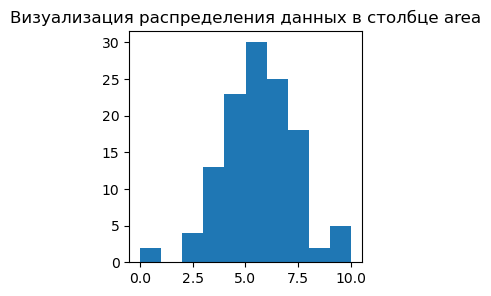

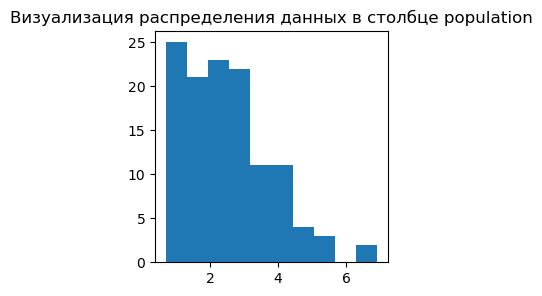

In [41]:
for column in  ['area','population']:
    plt.figure(figsize=(3,3))
    plt.hist(flag_data[column])
    plt.title(f"Визуализация распределения данных в столбце {column}")
    plt.show()

Распределение данных стало близко к нормальному

Повторим обучение моделей и посмотрим, как изменились метрики

In [42]:
X_new = flag_data[[
    "landmas",
    "zone",
    "area",
    "population",
    "language"]]
Y_new = flag_data['religion']

In [43]:
X_new.describe()

,landmas,zone,area,population,language
count,122.000000,122.000000,122.000000,122.000000,122.000000
mean,3.622951,1.991803,5.646776,2.450892,5.901639
std,1.356514,1.262923,1.720339,1.289732,3.288874
min,1.000000,1.000000,0.000000,0.693147,1.000000
25%,3.000000,1.000000,4.695893,1.609438,2.250000
50%,4.000000,1.000000,5.705446,2.249905,6.000000
75%,5.000000,3.000000,6.813714,3.293667,9.750000
max,6.000000,4.000000,10.016906,6.915723,10.000000


In [44]:
X_train_new,X_test_new,y_train_new, y_test_new = train_test_split(X_new,Y_new,test_size=0.2,random_state=42)

In [45]:
X_train_new.describe()

,landmas,zone,area,population,language
count,97.000000,97.000000,97.000000,97.000000,97.000000
mean,3.649485,2.000000,5.596683,2.450017,5.742268
std,1.361993,1.274755,1.678358,1.197941,3.333162
min,1.000000,1.000000,0.000000,0.693147,1.000000
25%,3.000000,1.000000,4.709530,1.609438,2.000000
50%,4.000000,1.000000,5.707110,2.302585,6.000000
75%,5.000000,3.000000,6.663133,3.091042,9.000000
max,6.000000,4.000000,9.207937,6.915723,10.000000


In [46]:
tree_model.fit(X_train_new,y_train_new)

DecisionTreeClassifier(max_depth=8)

In [47]:
y_pred_tree_new =tree_model.predict(X_test_new)

In [48]:
tree_model.score(X_test_new,y_test_new)

0.56

In [49]:
print(classification_report(y_test_new,y_pred_tree_new))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       0.00      0.00      0.00         2
           2       0.67      0.86      0.75         7
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           5       0.50      0.33      0.40         3
           6       0.40      0.40      0.40         5

    accuracy                           0.56        25
   macro avg       0.33      0.37      0.34        25
weighted avg       0.47      0.56      0.50        25



Метрики упали, что очень странно

In [50]:
model_log.fit(X_train_new,y_train_new)

LogisticRegression()

In [51]:
y_pred_log_new = model_log.predict(X_test_new)

In [52]:
model_log.score(X_test_new,y_test_new)

0.4

In [53]:
print(classification_report(y_test_new,y_pred_log_new))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       0.00      0.00      0.00         2
           2       0.40      0.29      0.33         7
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           5       0.29      0.67      0.40         3
           6       0.50      0.20      0.29         5

    accuracy                           0.40        25
   macro avg       0.27      0.31      0.26        25
weighted avg       0.39      0.40      0.37        25



Метрики повысились почти в 2 раза, что демонстрирует предположение о проблемах с данными, из-за которых были плохие показатели

In [54]:
svc_model.fit(X_train_new,y_train_new)

SVC()

In [55]:
y_pred_svc_new = svc_model.predict(X_test_new)

In [56]:
svc_model.score(X_test_new,y_test_new)

0.48

In [57]:
print(classification_report(y_test_new,y_pred_svc_new))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.00      0.00      0.00         2
           2       0.56      0.71      0.62         7
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           5       0.43      1.00      0.60         3
           6       0.00      0.00      0.00         5

    accuracy                           0.48        25
   macro avg       0.24      0.36      0.28        25
weighted avg       0.34      0.48      0.39        25



Метрики модели svc также снизились

По необъяснимым причинам метрики моделей дерева решений и модели опорных векторов уменьшились, а метрики модели логистической регрессии выросли. Попробуем сбалансировать классы и посмотреть, как изменятся метрики

In [58]:
flag_data['religion'].value_counts()

religion
0    29
2    27
5    20
1    18
6    15
3     7
7     4
4     2
Name: count, dtype: int64

In [59]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Пример: X — признаки, y — целевые метки
print("До oversampling:", Counter(Y_new))

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_new, Y_new)

print("После oversampling:", Counter(y_resampled))

До oversampling: Counter({0: 29, 2: 27, 5: 20, 1: 18, 6: 15, 3: 7, 7: 4, 4: 2})
После oversampling: Counter({6: 29, 2: 29, 5: 29, 0: 29, 1: 29, 3: 29, 4: 29, 7: 29})


Обучим модели на новом наборе

In [60]:
X_train_resampled,X_test_resampled,y_train_resampled, y_test_resampled = train_test_split(X_resampled, y_resampled,test_size=0.2,random_state=42)

In [61]:
def learning(X_tr,y_tr,X_ts,y_ts):
    tree_model.fit(X_tr,y_tr)
    y_pred_tree_res = tree_model.predict(X_ts)
    print(f"Метрики модели дерева решений",classification_report(y_ts,y_pred_tree_res))
    print('-------')

    model_log.fit(X_tr,y_tr)
    y_pred_log_res = model_log.predict(X_ts)
    print(f"Метрики модели логистической регрессии",classification_report(y_ts,y_pred_log_res))
    print('-------')

    svc_model.fit(X_tr,y_tr)
    y_pred_svc_res = svc_model.predict(X_ts)
    print(f"Метрики модели SVC",classification_report(y_ts,y_pred_svc_res))
    print('-------')


In [62]:
learning(X_train_resampled, y_train_resampled, X_test_resampled,y_test_resampled)

Метрики модели дерева решений               precision    recall  f1-score   support

           0       0.33      1.00      0.50         2
           1       0.80      0.57      0.67         7
           2       0.67      0.80      0.73         5
           3       0.88      1.00      0.93         7
           4       1.00      1.00      1.00         7
           5       0.67      0.50      0.57         8
           6       0.60      0.43      0.50         7
           7       1.00      1.00      1.00         4

    accuracy                           0.74        47
   macro avg       0.74      0.79      0.74        47
weighted avg       0.77      0.74      0.74        47

-------
Метрики модели логистической регрессии               precision    recall  f1-score   support

           0       0.33      1.00      0.50         2
           1       0.60      0.43      0.50         7
           2       0.00      0.00      0.00         5
           3       0.67      0.29      0.40         7
 

Метрики модели дерева решений существенно повысились, а метрики моделей лог.регрессии и svc упали.

Размерность пространства признаков уменьшить можно, выбрав наиболее значимые признаки. Выполним отбор через алгоритм случайного леса и встроенную в него функцию

In [63]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=1)
rf = model_rf.fit(flag_data.drop(columns=['name','religion','mainhue','topleft','botright']), flag_data['religion'])

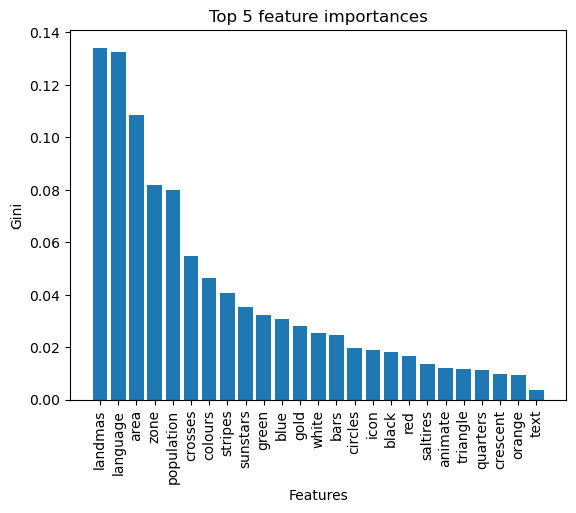

In [64]:
imp = pd.Series(rf.feature_importances_, index=flag_data.drop(columns=['name','religion','mainhue','topleft','botright']).columns)
imp = imp.sort_values(ascending=False)

plt.title('Top 5 feature importances')
plt.xlabel('Features')
plt.ylabel('Gini')
plt.bar(imp.index, imp)
plt.xticks(rotation = 90)
plt.show()

Возьмем для обучения модели первые три признака

In [65]:
X_resampled_new, y_resampled_new = ros.fit_resample(X_new[['landmas','language','area']], Y_new)
X_train_resampled_new,X_test_resampled_new,y_train_resampled_new, y_test_resampled_new = train_test_split(X_resampled_new, y_resampled_new,test_size=0.2,random_state=42)

In [66]:
learning(X_train_resampled_new, y_train_resampled_new, X_test_resampled_new,y_test_resampled_new)

Метрики модели дерева решений               precision    recall  f1-score   support

           0       0.33      1.00      0.50         2
           1       0.75      0.43      0.55         7
           2       0.50      1.00      0.67         5
           3       1.00      0.43      0.60         7
           4       1.00      1.00      1.00         7
           5       1.00      0.50      0.67         8
           6       0.38      0.43      0.40         7
           7       0.80      1.00      0.89         4

    accuracy                           0.66        47
   macro avg       0.72      0.72      0.66        47
weighted avg       0.77      0.66      0.66        47

-------
Метрики модели логистической регрессии               precision    recall  f1-score   support

           0       0.29      1.00      0.44         2
           1       0.75      0.43      0.55         7
           2       0.00      0.00      0.00         5
           3       0.67      0.29      0.40         7
 

Все метрики упали, поэтому лучше использовать 5 признаков для обучения

Найдем оптимальные параметры для моделей

In [67]:
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier

In [68]:
models= [ 
      {'name':'LR',"model": model_log,
        'params': {'penalty':['l1', 'l2', 'elasticnet', None]}},
      {'name':'SVC',"model": svc_model, 
       'params':
       {'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],}},
      {'name':'DT',"model": tree_model,
        'params':
       {'min_samples_split':[1,5,10,15,20], 'criterion':['gini', 'entropy'], 'max_depth':[3,5,7,9,11]}}

]

res=[]
for v in  tqdm(models):
    tmp_model = RandomizedSearchCV(v['model'], v['params'], cv=5)
    tmp_model.fit(X_train_resampled, y_train_resampled)
    res.append(((v['name'], tmp_model, {'metrics':{'accuracy': accuracy_score(tmp_model.predict(X_test_resampled), y_test_resampled),
                                                 'f1-score':f1_score(tmp_model.predict(X_test_resampled), y_test_resampled,average='macro')}})))

100%|██████████| 3/3 [00:00<00:00,  9.57it/s]


In [69]:
res

[('LR',
  RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                     param_distributions={'penalty': ['l1', 'l2', 'elasticnet',
                                                      None]}),
  {'metrics': {'accuracy': 0.40425531914893614,
    'f1-score': 0.390018315018315}}),
 ('SVC',
  RandomizedSearchCV(cv=5, estimator=SVC(),
                     param_distributions={'kernel': ['linear', 'poly', 'rbf',
                                                     'sigmoid']}),
  {'metrics': {'accuracy': 0.6595744680851063,
    'f1-score': 0.6056412337662338}}),
 ('DT',
  RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=8),
                     param_distributions={'criterion': ['gini', 'entropy'],
                                          'max_depth': [3, 5, 7, 9, 11],
                                          'min_samples_split': [1, 5, 10, 15,
                                                                20]}),
  {'metrics': {'accuracy': 0.74468085106

In [70]:
for r in res:
    print(r[0], r[1].best_score_, r[1].best_params_)




LR 0.48108108108108105 {'penalty': 'l2'}
SVC 0.6756756756756757 {'kernel': 'poly'}
DT 0.7621621621621621 {'min_samples_split': 5, 'max_depth': 9, 'criterion': 'gini'}


In [82]:
DT_best = DecisionTreeClassifier(min_samples_split= 5, max_depth=9, criterion= 'gini',random_state=10)
DT_best.fit(X_train_resampled,y_train_resampled)

precision_best_DT = precision_score(y_test_resampled,DT_best.predict(X_test_resampled),average='macro')
recall_best_DT= recall_score(y_test_resampled,DT_best.predict(X_test_resampled),average='macro')
print(f"Точность на обучающей выборке - {DT_best.score(X_train_resampled,y_train_resampled):.2f}, точность на тестовой выборке - {DT_best.score(X_test_resampled,y_test_resampled):.5f}")
print(f"Precision - {precision_best_DT:.2f},recall - {precision_best_DT:.2f}")


Точность на обучающей выборке - 0.92, точность на тестовой выборке - 0.74468
Precision - 0.75,recall - 0.75


Наилучшие метрики показала модель Decision Tree с параметрами: минимальное число объектов для разбиения - 5, глубина дерева - 11, информационный критерий - энтропия


Обучение стекинга 3 моделей. 

Первый стекинг: 
1) Первая модель - улучшенная модель DT с найденными параметрами.
2)  Вторая модель - модель классификации SVC c найденными параметрами.
3) Третья модель - модель логистической регрессии c найденными параметрами. 

Второй стекинг: 
1) Случайный лес
2) Дерево решений с найденными параметрами
3) Метод опорных векторов SVC c найденными параметрами

Объединять модели будет модель второго уровня  RidgeClassifier

In [72]:
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import StackingClassifier



In [73]:

stacking_classifer_1 = StackingClassifier(
    [
        ('Logistic Regression', LogisticRegression(random_state=10,penalty='l2')),
        ('Support Vector Classification.C', SVC(kernel='poly',random_state=10)),
        ('DecisionTree', DecisionTreeClassifier(min_samples_split= 5, max_depth=9, criterion= 'gini',random_state=10))
    ], RidgeClassifier())

In [74]:
stacking_classifer_1.fit(X_train_resampled,y_train_resampled)

StackingClassifier(estimators=[('Logistic Regression',
                                LogisticRegression(random_state=10)),
                               ('Support Vector Classification.C',
                                SVC(kernel='poly', random_state=10)),
                               ('DecisionTree',
                                DecisionTreeClassifier(max_depth=9,
                                                       min_samples_split=5,
                                                       random_state=10))],
                   final_estimator=RidgeClassifier())

In [79]:
precision_stacking = precision_score(y_test_resampled,stacking_classifer_1.predict(X_test_resampled),average='macro')
recall_stacking= recall_score(y_test_resampled,stacking_classifer_1.predict(X_test_resampled),average='macro')
print(f"Точность на обучающей выборке - {stacking_classifer_1.score(X_train_resampled,y_train_resampled):.2f}, точность на тестовой выборке - {stacking_classifer_1.score(X_test_resampled,y_test_resampled):.5f}")
print(f"Precision - {precision_stacking:.2f},recall - {precision_stacking:.2f}")

Точность на обучающей выборке - 0.91, точность на тестовой выборке - 0.74468
Precision - 0.76,recall - 0.76


Метрики увеличились незначительно, в пределах одного процента. Проверим, как изменятся метрики при втором стекинге

Первым делом необходимо подобрать наилучшие параметры для модели случайного леса

In [84]:

param = {'n_estimators':[1,5,10,20],
    'max_features':[0.1,0.5,0.7,1],
    'max_samples':[0.1,0.5,0.7,1]}

model_best_param = RandomizedSearchCV(RandomForestClassifier(), param, cv=5)
model_best_param.fit(X_train_resampled, y_train_resampled)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_features': [0.1, 0.5, 0.7, 1],
                                        'max_samples': [0.1, 0.5, 0.7, 1],
                                        'n_estimators': [1, 5, 10, 20]})

In [87]:
print(f'RF, score- {model_best_param.best_score_:.2f}, лучшие параметры - {model_best_param.best_params_}')

RF, score- 0.79, лучшие параметры - {'n_estimators': 10, 'max_samples': 0.7, 'max_features': 0.5}


In [88]:
stacking_classifer_2 = StackingClassifier(
    [
        ('Random Forest', RandomForestClassifier(n_estimators=10,max_samples=0.7,max_features=0.5)),
        ('Support Vector Classification.C', SVC(kernel='poly',random_state=10)),
        ('DecisionTree', DecisionTreeClassifier(min_samples_split= 5, max_depth=9, criterion= 'gini',random_state=10))
    ], RidgeClassifier())

In [89]:
stacking_classifer_2.fit(X_train_resampled,y_train_resampled)

StackingClassifier(estimators=[('Random Forest',
                                RandomForestClassifier(max_features=0.5,
                                                       max_samples=0.7,
                                                       n_estimators=10)),
                               ('Support Vector Classification.C',
                                SVC(kernel='poly', random_state=10)),
                               ('DecisionTree',
                                DecisionTreeClassifier(max_depth=9,
                                                       min_samples_split=5,
                                                       random_state=10))],
                   final_estimator=RidgeClassifier())

In [92]:
precision_stacking_2 = precision_score(y_test_resampled,stacking_classifer_2.predict(X_test_resampled),average='macro')
recall_stacking_2= recall_score(y_test_resampled,stacking_classifer_2.predict(X_test_resampled),average='macro')
print(f"Точность на обучающей выборке - {stacking_classifer_2.score(X_train_resampled,y_train_resampled):.2f}, точность на тестовой выборке - {stacking_classifer_2.score(X_test_resampled,y_test_resampled):.5f}")
print(f"Precision - {precision_stacking_2:.2f},recall - {precision_stacking_2:.2f}")

Точность на обучающей выборке - 0.97, точность на тестовой выборке - 0.80851
Precision - 0.82,recall - 0.82


Метрики выросли значительно.

Заключительно посмотрим, насколько эффективно будет работать градиентный бустинг.

In [91]:
from sklearn.ensemble import GradientBoostingClassifier

boosting = GradientBoostingClassifier(n_estimators=100,
                                     random_state=10,learning_rate=0.01,)
boosting.fit(X_train_resampled,y_train_resampled)

GradientBoostingClassifier(learning_rate=0.01, random_state=10)

In [93]:
precision_boosting = precision_score(y_test_resampled,boosting.predict(X_test_resampled),average='macro')
recall_boosting= recall_score(y_test_resampled,boosting.predict(X_test_resampled),average='macro')
print(f"Точность на обучающей выборке - {boosting.score(X_train_resampled,y_train_resampled):.2f}, точность на тестовой выборке - {boosting.score(X_test_resampled,y_test_resampled):.5f}")
print(f"Precision - {precision_stacking:.2f},recall - {precision_stacking:.2f}")

Точность на обучающей выборке - 0.90, точность на тестовой выборке - 0.63830
Precision - 0.82,recall - 0.82


Точности на обучающей и тестовой выборках упала.

Наилучшая модель - модель стекинга случайного леса, дерева решений и SVC модели. Выведем для нее матрицу ошибок

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay

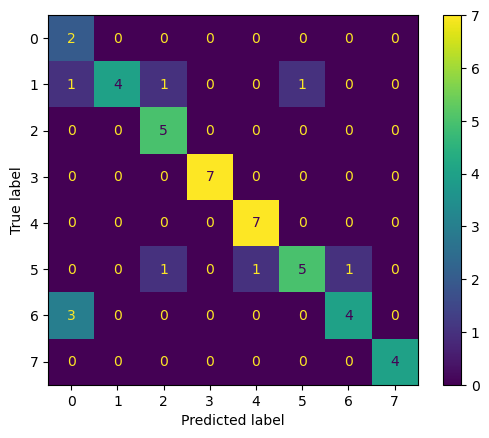

In [99]:
y_pred_stacking = stacking_classifer_2.predict(X_test_resampled)
matrix = ConfusionMatrixDisplay.from_estimator(stacking_classifer_2, X_test_resampled, y_test_resampled)


По матрице видно, что неверно определен класс у 11 объектов тестовой выборки. Класс 6 неверно был предсказан 3 раза, класс 5 - 3 раза, класс 1 - 6 раз.

Посмотрим матрицу ошибок для самой слабой модели - модели логистической регрессии. 

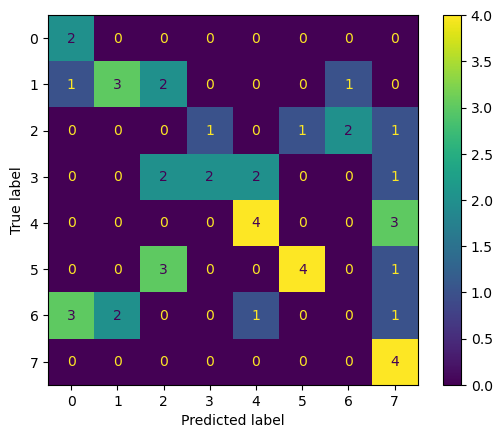

In [104]:
model_log_res = LogisticRegression(random_state=10,penalty='l2')
model_log_res.fit(X_train_resampled,y_train_resampled)
matrix_log = ConfusionMatrixDisplay.from_estimator(model_log_res, X_test_resampled, y_test_resampled)

По второй матрице видно, что модель очень плохо справляется с поставленной задачей

Вывод: в ходе выполнения финальной работы по модулю была проведена классификация данных по религии. Для качественной классификации был проведен первичный анализ данных (исследованы данные на пропуски, обработаны выбросы в данных (заменены медианой по группам)), проведена нормализация признаков, которые не имели нормального распределения, были сбалансированы классы с помощью orevsampling, уменьшена размерность признаков с помощью встроенного метода по поиску важных признаков алгоритма случайного леса, проведен отбор параметров с помощью рандомного поиска, а так же обучено два стекинга моделей и градиентный бустинг и построены матрицы ошибок для самой лучшей модели и самой худшей. Таким образом, можно сделать вывод, что самый лучший результат показала модель стекинга для 3-х моделей - случайного леса, деревья решений и метод опорных векторов - на данных с 5 самыми важными нормализированными признаками, в которых отсутствуют выбросы и пропуски. Такая модель имеет метрики: точность на обучающей выборке - 0.97, точность на тестовой выборке - 0.81, precision - 0.82, recall - 0.82. Характеристики и параметры модели отображены выше